In [3]:
%pip install pymupdf pytesseract pandas pillow

  Using cached pymupdf-1.28.2-cp310-abi3-win_amd64.whl.metadata (26 kB)
  Using cached pytesseract-0.3.13-py3-none-any.whl.metadata (11 kB)
Using cached pymupdf-1.28.2-cp310-abi3-win_amd64.whl (19.8 MB)
Using cached pytesseract-0.3.13-py3-none-any.whl (14 kB)

   -------------------- ------------------- 1/2 [pymupdf]
   -------------------- ------------------- 1/2 [pymupdf]
   -------------------- ------------------- 1/2 [pymupdf]
   -------------------- ------------------- 1/2 [pymupdf]
   -------------------- ------------------- 1/2 [pymupdf]
   -------------------- ------------------- 1/2 [pymupdf]
   -------------------- ------------------- 1/2 [pymupdf]
   -------------------- ------------------- 1/2 [pymupdf]
   ---------------------------------------- 2/2 [pymupdf]

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

desktop = Path(r"C:\Users\USER\Desktop")
tesseract_files = list(desktop.rglob("tesseract.exe"))

for file in tesseract_files:
    print(file)

C:\Users\USER\Desktop\tesseract.exe


In [3]:
import pytesseract

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Users\USER\Desktop\tesseract.exe"
)

print(pytesseract.get_tesseract_version())

5.5.3.20260724


In [5]:
from pathlib import Path

pdf_path = Path(r"C:\Users\USER\Desktop\chirundu_obb_2023.pdf.pdf")

print(pdf_path.exists())

True


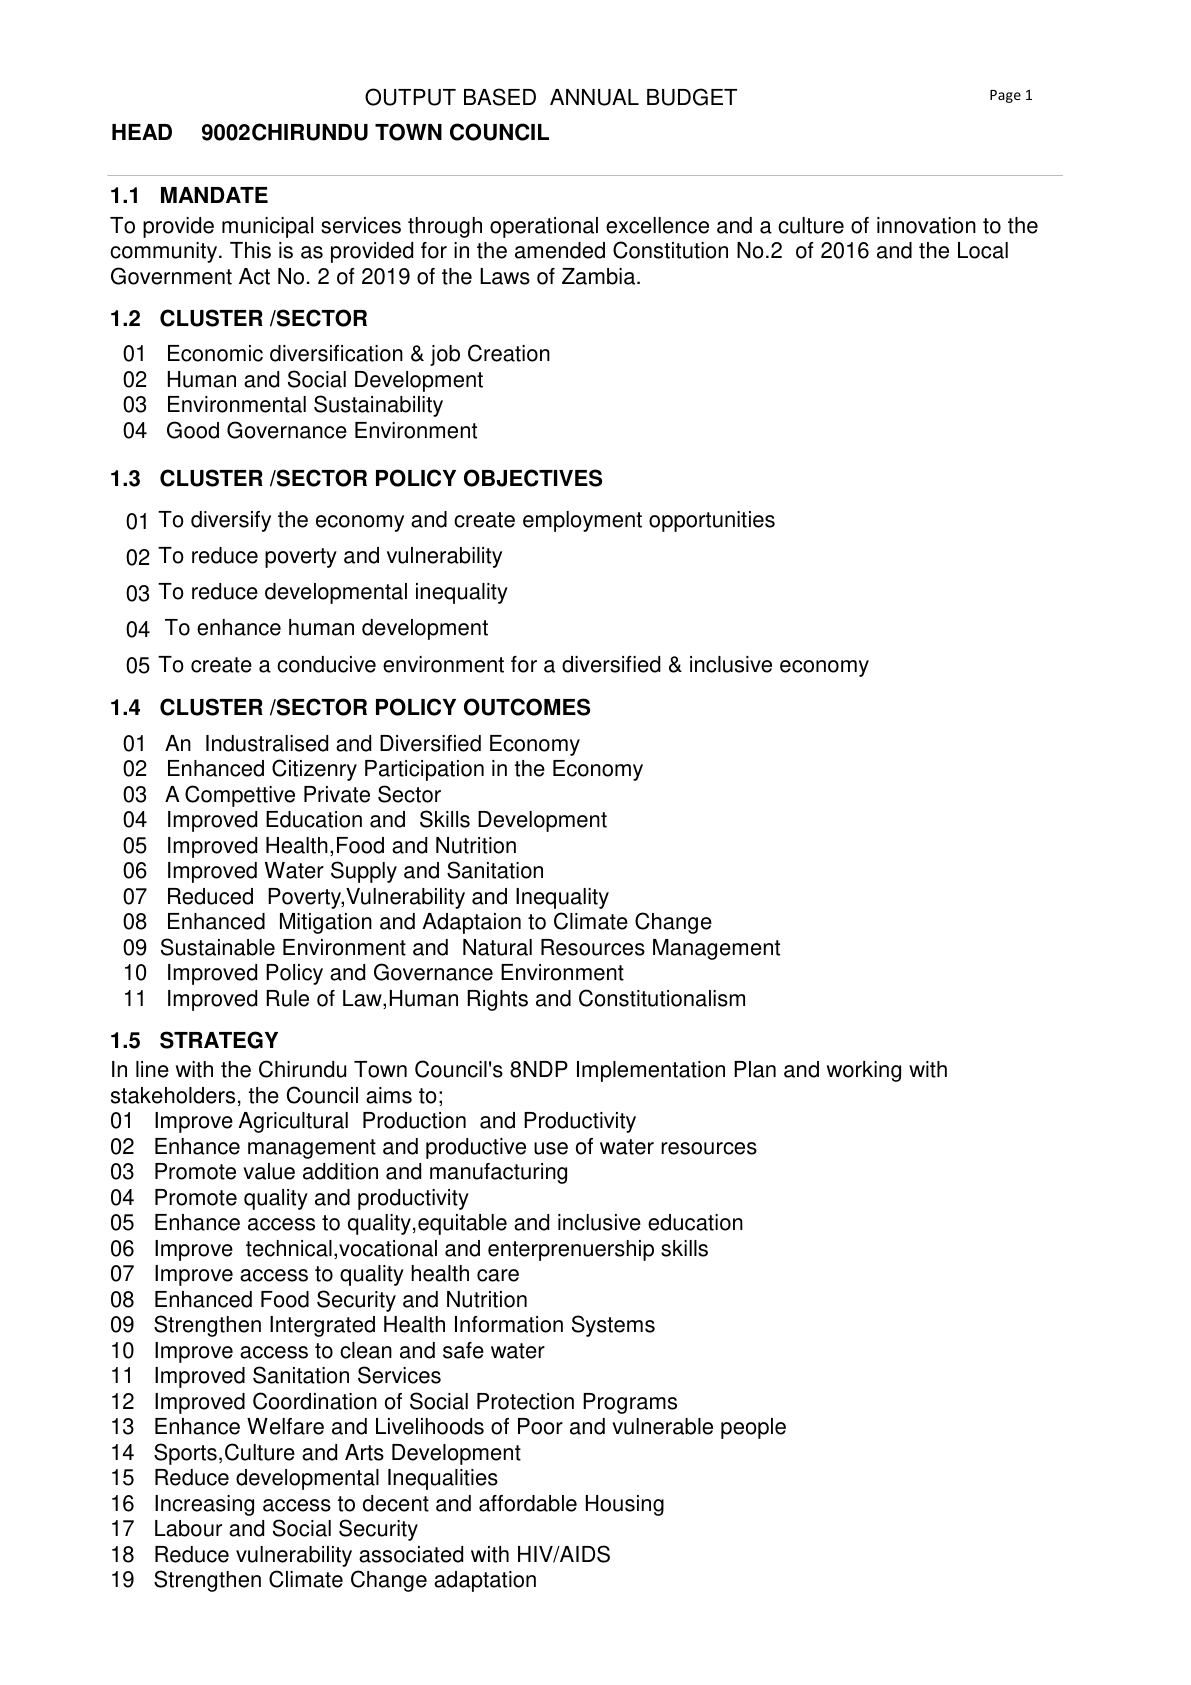

OUTPUT BASED ANNUAL BUDGET Page 1
HEAD 9002CHIRUNDU TOWN COUNCIL

1.1. MANDATE

To provide municipal services through operational excellence and a culture of innovation to the
community. This is as provided for in the amended Constitution No.2 of 2016 and the Local
Government Act No. 2 of 2019 of the Laws of Zambia.

1.2 CLUSTER /SECTOR

01 Economic diversification & job Creation
02 Human and Social Development

03 Environmental Sustainability

04 Good Governance Environment

1.3. CLUSTER /SECTOR POLICY OBJECTIVES
01 To diversify the economy and create employment opportunities
02 To reduce poverty and vulnerability
03 To reduce developmental inequality
04 To enhance human development
05 To create a conducive environment for a diversified & inclusive economy

1.4 CLUSTER /SECTOR POLICY OUTCOMES

01 An Industralised and Diversified Economy

02 Enhanced Citizenry Participation in the Economy

03 ACompettive Private Sector

04 Improved Education and Skills Development

05 Improved Health,F

In [6]:
import pymupdf
import pytesseract
from PIL import Image
import io
from IPython.display import display

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Users\USER\Desktop\tesseract.exe"
)

document = pymupdf.open(pdf_path)

page = document.load_page(0)
pix = page.get_pixmap(matrix=pymupdf.Matrix(2, 2), alpha=False)

image = Image.open(io.BytesIO(pix.tobytes("png")))
display(image)

first_page_text = pytesseract.image_to_string(image, lang="eng")

print(first_page_text)

In [7]:
from pathlib import Path
import pymupdf
import pytesseract
import pandas as pd
from PIL import Image
import io

output_folder = Path(r"C:\Users\USER\Videos\chitundu\output_2023")
output_folder.mkdir(exist_ok=True)

document = pymupdf.open(pdf_path)
ocr_rows = []

for page_number, page in enumerate(document, start=1):
    pix = page.get_pixmap(matrix=pymupdf.Matrix(2, 2), alpha=False)
    image = Image.open(io.BytesIO(pix.tobytes("png")))

    text = pytesseract.image_to_string(image, lang="eng")

    ocr_rows.append({
        "year": 2023,
        "page": page_number,
        "ocr_text": text,
        "source_file": pdf_path.name
    })

    print(f"Finished page {page_number} of {len(document)}")

raw_ocr = pd.DataFrame(ocr_rows)

raw_csv = output_folder / "chirundu_obb_2023_raw_ocr.csv"
raw_ocr.to_csv(raw_csv, index=False)

print(f"\nSaved: {raw_csv}")
print(f"Total pages OCR'd: {len(raw_ocr)}")

Finished page 1 of 31
Finished page 2 of 31
Finished page 3 of 31
Finished page 4 of 31
Finished page 5 of 31
Finished page 6 of 31
Finished page 7 of 31
Finished page 8 of 31
Finished page 9 of 31
Finished page 10 of 31
Finished page 11 of 31
Finished page 12 of 31
Finished page 13 of 31
Finished page 14 of 31
Finished page 15 of 31
Finished page 16 of 31
Finished page 17 of 31
Finished page 18 of 31
Finished page 19 of 31
Finished page 20 of 31
Finished page 21 of 31
Finished page 22 of 31
Finished page 23 of 31
Finished page 24 of 31
Finished page 25 of 31
Finished page 26 of 31
Finished page 27 of 31
Finished page 28 of 31
Finished page 29 of 31
Finished page 30 of 31
Finished page 31 of 31

Saved: C:\Users\USER\Videos\chitundu\output_2023\chirundu_obb_2023_raw_ocr.csv
Total pages OCR'd: 31


In [8]:
check_2023 = pd.read_csv(raw_csv)

print(check_2023[["year", "page", "source_file"]].head())
print("Rows:", len(check_2023))


   year  page                source_file
0  2023     1  chirundu_obb_2023.pdf.pdf
1  2023     2  chirundu_obb_2023.pdf.pdf
2  2023     3  chirundu_obb_2023.pdf.pdf
3  2023     4  chirundu_obb_2023.pdf.pdf
4  2023     5  chirundu_obb_2023.pdf.pdf
Rows: 31


In [9]:
keywords = [
    "revenue",
    "local revenue",
    "cdf",
    "constituency development fund",
    "lgef",
    "local government equalisation fund",
    "programme",
    "program",
    "output"
]

for keyword in keywords:
    matching_pages = raw_ocr[
        raw_ocr["ocr_text"].str.contains(keyword, case=False, na=False)
    ]["page"].tolist()

    print(f"{keyword.upper()}: {matching_pages}")

REVENUE: [6, 10, 16, 30, 31]
LOCAL REVENUE: [30]
CDF: [20]
CONSTITUENCY DEVELOPMENT FUND: [5]
LGEF: []
LOCAL GOVERNMENT EQUALISATION FUND: []
PROGRAMME: [5, 6, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
PROGRAM: [1, 5, 6, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
OUTPUT: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]



PAGE 30


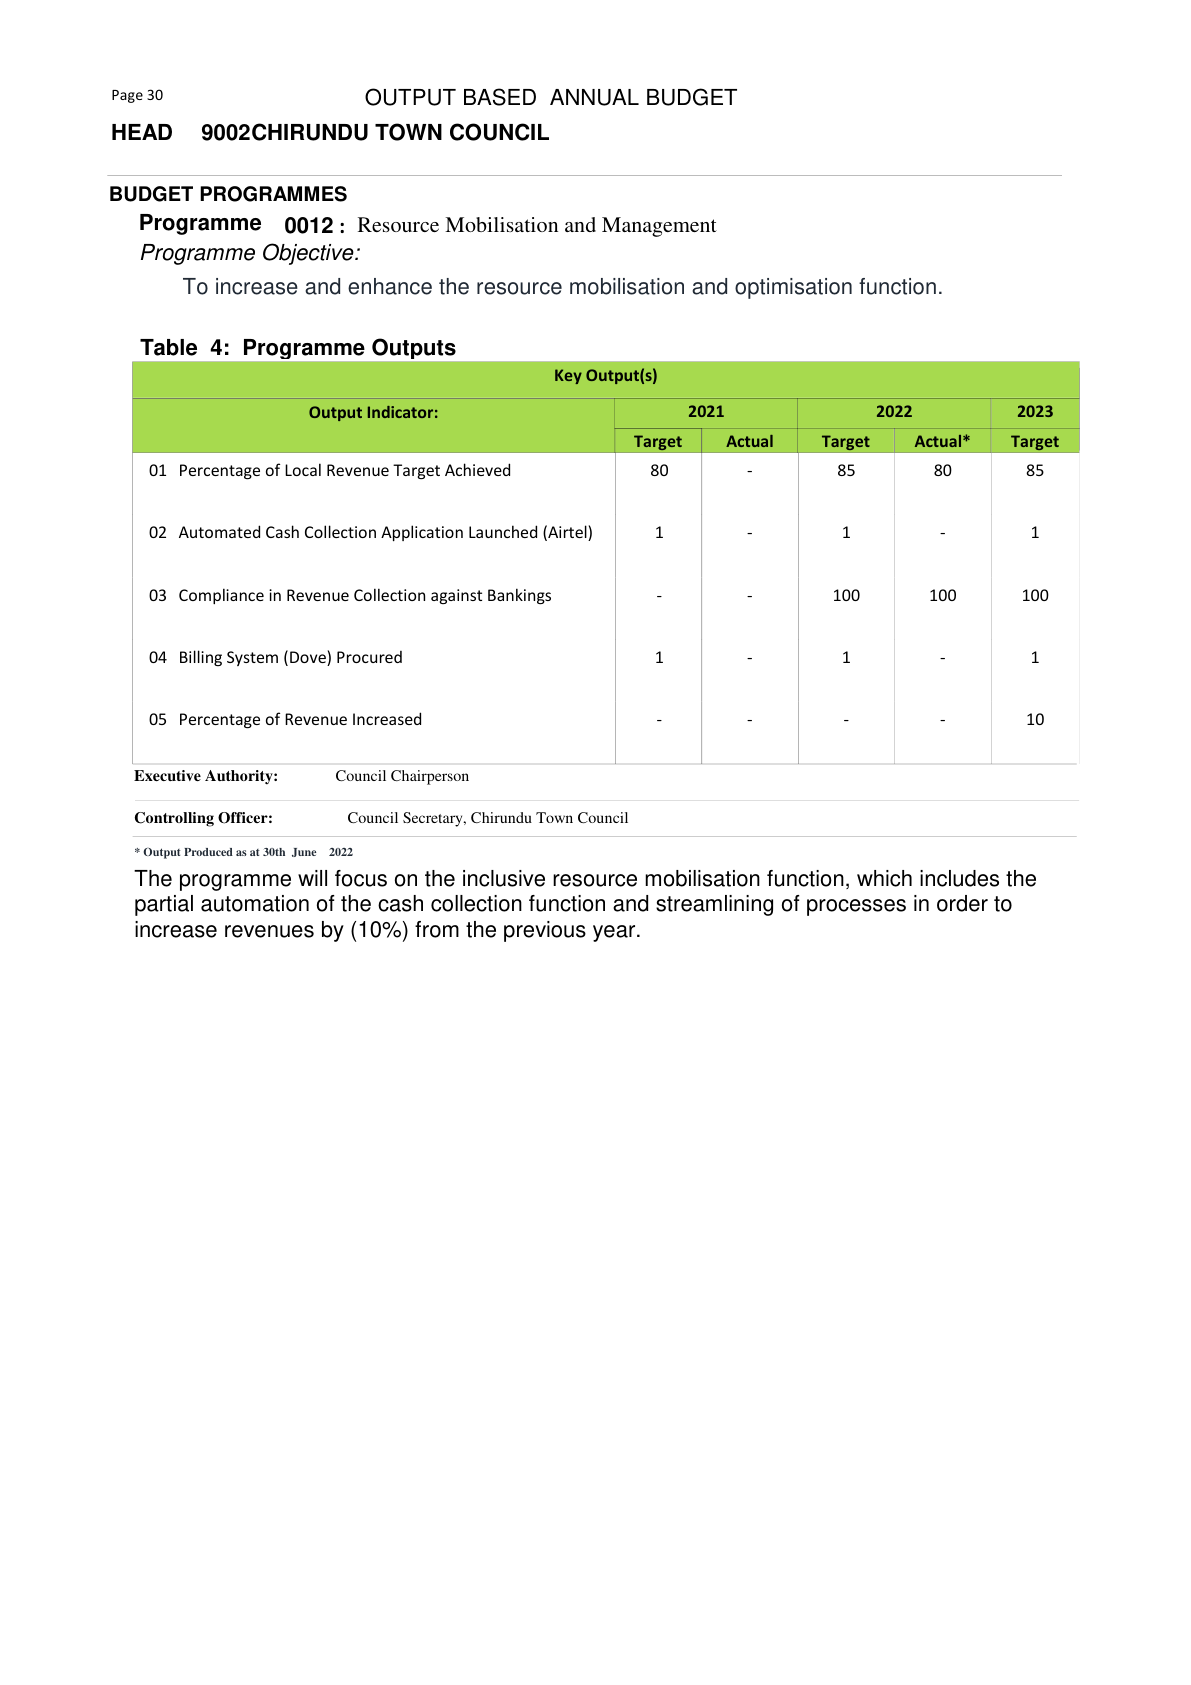

Page 30 OUTPUT BASED ANNUAL BUDGET

HEAD 9002CHIRUNDU TOWN COUNCIL

BUDGET PROGRAMMES

Programme 0012: Resource Mobilisation and Management

Programme Objective:

To increase and enhance the resource mobilisation and optimisation function.

Table 4: Programme Outputs

01 Percentage of Local Revenue Target Achieved

02 Automated Cash Collection Application Launched (Airtel)
03 Compliance in Revenue Collection against Bankings

04. Billing System (Dove) Procured

05. Percentage of Revenue Increased

Executive Authority: Council Chairperson

Controlling Officer: Council Secretary, Chirundu Town Council

* Output Produced as at 30th June 2022

80

85

100

80

100

85

100

10

The programme will focus on the inclusive resource mobilisation function, which includes the

partial automation of the cash collection function and streamlining of processes in order to

increase revenues by (10%) from the previous year.


PAGE 31


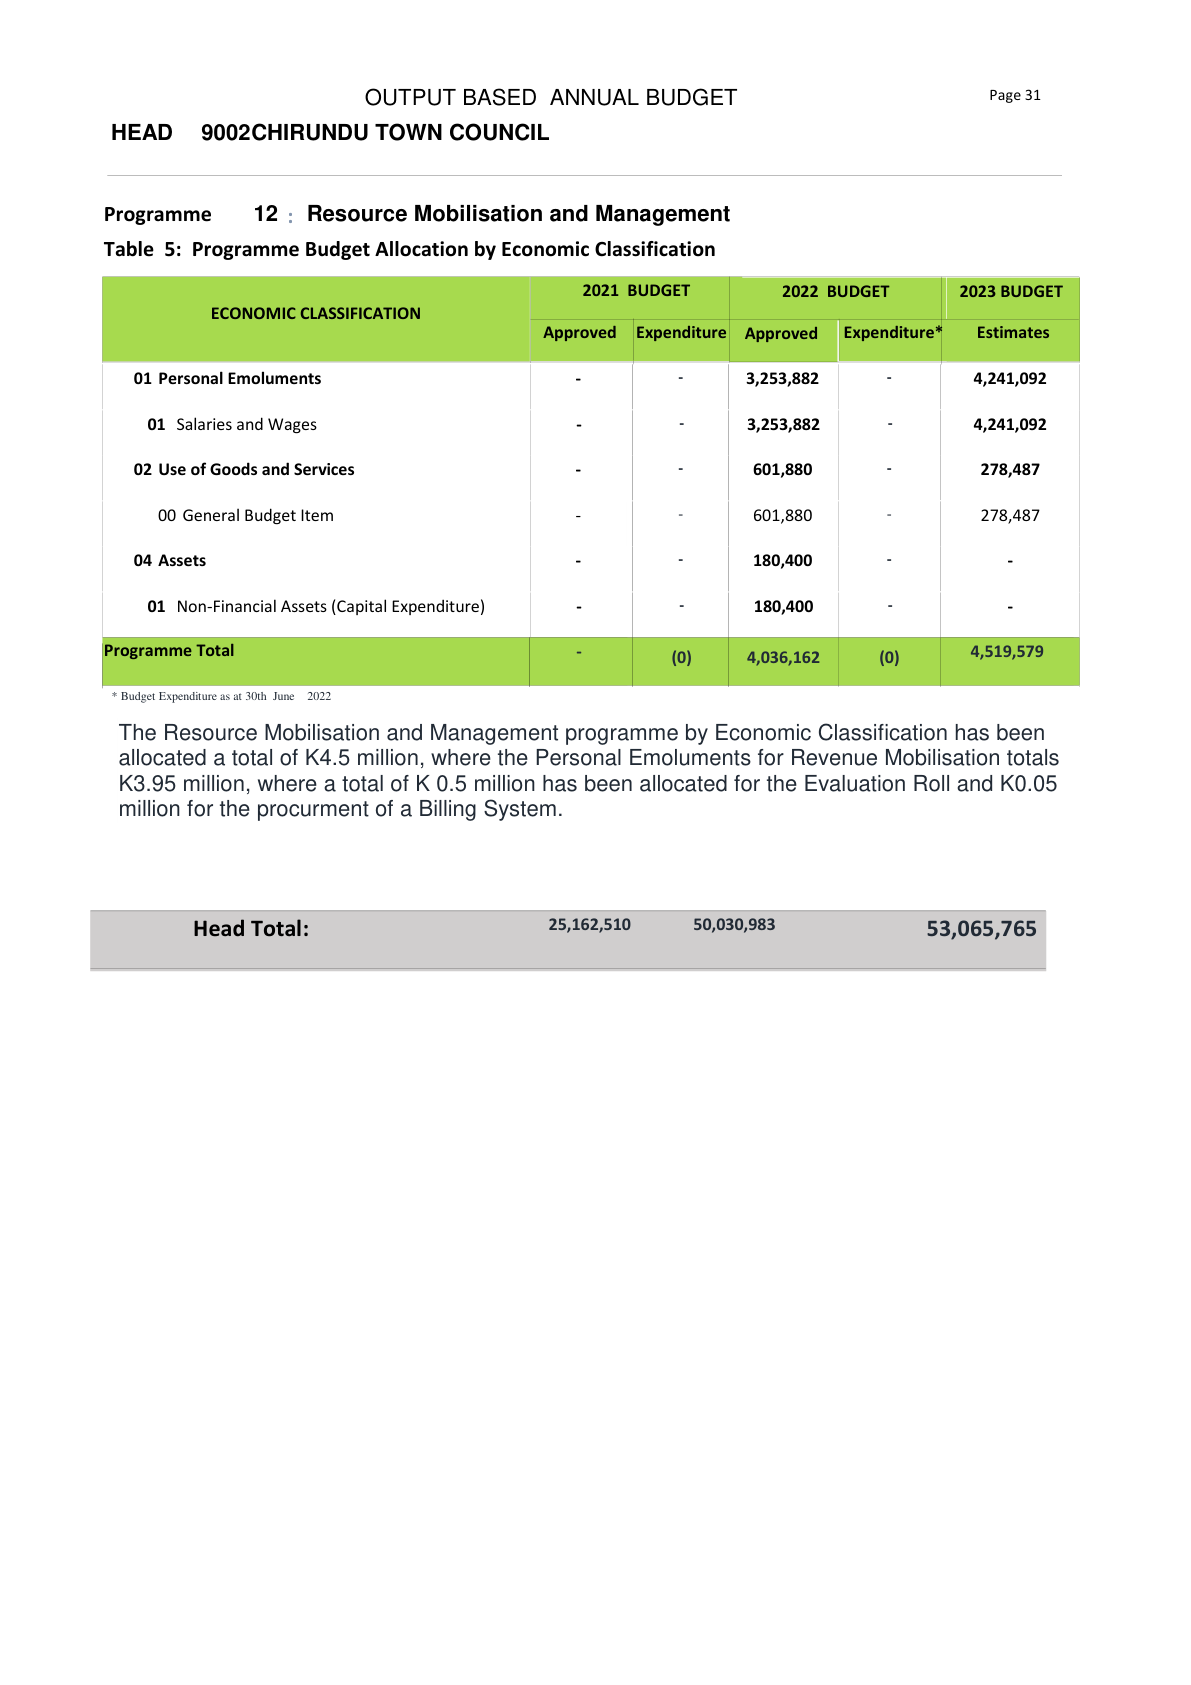

OUTPUT BASED ANNUAL BUDGET Page 31
HEAD 9002CHIRUNDU TOWN COUNCIL

Programme 12 : Resource Mobilisation and Management
Table 5: Programme Budget Allocation by Economic Classification

01 Personal Emoluments - | | 3,253,882 : 4,241,092
01 Salaries and Wages - | | 3,253,882 : 4,241,092
02 Use of Goods and Services - | - | 601,880 : 278,487
00 General Budget Item - | | 601,880 - 278,487
04 Assets - | | 180,400 : -
01 Non-Financial Assets (Capital Expenditure) : - 180,400 - :

* Budget Expenditure as at 30th June 2022

The Resource Mobilisation and Management programme by Economic Classification has been
allocated a total of K4.5 million, where the Personal Emoluments for Revenue Mobilisation totals
K3.95 million, where a total of K 0.5 million has been allocated for the Evaluation Roll and K0.05
million for the procurment of a Billing System.

Head Total: esi) ELSEDEEE) 53,065,765




In [10]:
from IPython.display import display
import pymupdf
from PIL import Image
import io

document = pymupdf.open(pdf_path)

for page_number in [30, 31]:
    page = document.load_page(page_number - 1)  # PDF pages start at 0
    pix = page.get_pixmap(matrix=pymupdf.Matrix(2, 2), alpha=False)
    image = Image.open(io.BytesIO(pix.tobytes("png")))

    print(f"\n{'=' * 70}")
    print(f"PAGE {page_number}")
    print(f"{'=' * 70}")

    display(image)
    print(raw_ocr.loc[raw_ocr["page"] == page_number, "ocr_text"].iloc[0])

In [11]:
revenue_rows = [
    {
        "year": 2023,
        "category": "Local Revenue",
        "programme_or_output": "Resource Mobilisation and Management",
        "page": 30,
        "budget_amount": "",
        "currency": "ZMW",
        "notes": "Programme objective: increase and enhance resource mobilisation and optimisation.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Local Revenue Output",
        "programme_or_output": "Percentage of Local Revenue Target Achieved",
        "page": 30,
        "budget_amount": "",
        "currency": "",
        "notes": "Programme output.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Local Revenue Output",
        "programme_or_output": "Automated Cash Collection Application Launched (Airtel)",
        "page": 30,
        "budget_amount": "",
        "currency": "",
        "notes": "Programme output.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Local Revenue Output",
        "programme_or_output": "Compliance in Revenue Collection against Bankings",
        "page": 30,
        "budget_amount": "",
        "currency": "",
        "notes": "Programme output.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Local Revenue Output",
        "programme_or_output": "Billing System (Dove) Procured",
        "page": 30,
        "budget_amount": 50000,
        "currency": "ZMW",
        "notes": "Narrative on page 31 states K0.05 million was allocated for the billing system.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Local Revenue Output",
        "programme_or_output": "Percentage of Revenue Increased",
        "page": 30,
        "budget_amount": "",
        "currency": "",
        "notes": "Target: increase revenue by 10% from the previous year.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Local Revenue",
        "programme_or_output": "Resource Mobilisation and Management — total allocation",
        "page": 31,
        "budget_amount": 4500000,
        "currency": "ZMW",
        "notes": "Total programme allocation: K4.5 million.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Local Revenue",
        "programme_or_output": "Personal Emoluments for Revenue Mobilisation",
        "page": 31,
        "budget_amount": 3950000,
        "currency": "ZMW",
        "notes": "Narrative allocation: K3.95 million.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Local Revenue",
        "programme_or_output": "Evaluation Roll",
        "page": 31,
        "budget_amount": 500000,
        "currency": "ZMW",
        "notes": "Narrative allocation: K0.5 million.",
        "source_file": pdf_path.name
    }
]

final_2023 = pd.DataFrame(revenue_rows)
final_2023

,year,category,programme_or_output,page,budget_amount,currency,notes,source_file
0,2023,Local Revenue,Resource Mobilisation and Management,30,,ZMW,Programme objective: increase and enhance reso...,chirundu_obb_2023.pdf.pdf
1,2023,Local Revenue Output,Percentage of Local Revenue Target Achieved,30,,,Programme output.,chirundu_obb_2023.pdf.pdf
2,2023,Local Revenue Output,Automated Cash Collection Application Launched...,30,,,Programme output.,chirundu_obb_2023.pdf.pdf
3,2023,Local Revenue Output,Compliance in Revenue Collection against Bankings,30,,,Programme output.,chirundu_obb_2023.pdf.pdf
4,2023,Local Revenue Output,Billing System (Dove) Procured,30,50000,ZMW,Narrative on page 31 states K0.05 million was ...,chirundu_obb_2023.pdf.pdf
5,2023,Local Revenue Output,Percentage of Revenue Increased,30,,,Target: increase revenue by 10% from the previ...,chirundu_obb_2023.pdf.pdf
6,2023,Local Revenue,Resource Mobilisation and Management — total a...,31,4500000,ZMW,Total programme allocation: K4.5 million.,chirundu_obb_2023.pdf.pdf
7,2023,Local Revenue,Personal Emoluments for Revenue Mobilisation,31,3950000,ZMW,Narrative allocation: K3.95 million.,chirundu_obb_2023.pdf.pdf
8,2023,Local Revenue,Evaluation Roll,31,500000,ZMW,Narrative allocation: K0.5 million.,chirundu_obb_2023.pdf.pdf



PAGE 20


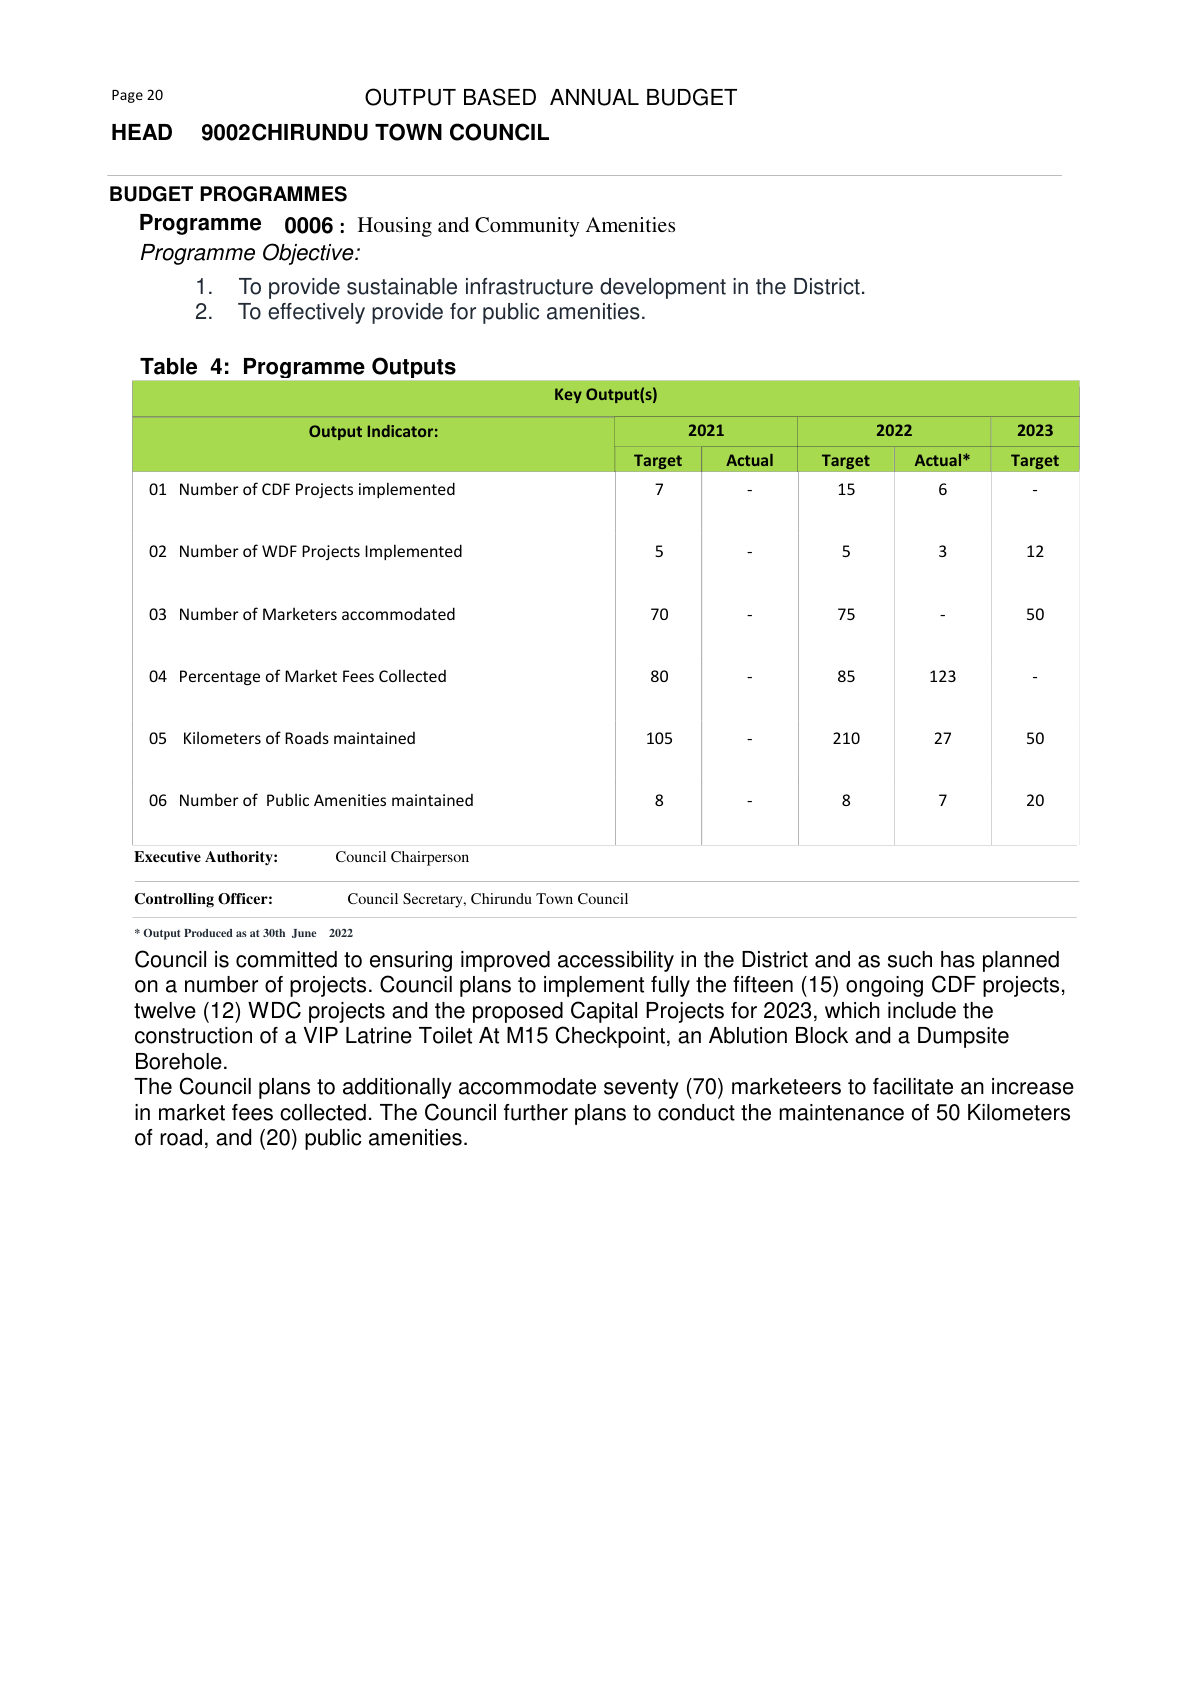

Page 20 OUTPUT BASED ANNUAL BUDGET
HEAD 9002CHIRUNDU TOWN COUNCIL

BUDGET PROGRAMMES
Programme 0006: Housing and Community Amenities
Programme Objective:

1. To provide sustainable infrastructure development in the District.
2. To effectively provide for public amenities.

Table 4: Programme Outputs

01 Number of CDF Projects implemented 7 - 15 6
02 Number of WDF Projects Implemented 5 - 5 3 12
03 Number of Marketers accommodated 70 - 75 50
04 Percentage of Market Fees Collected 80 - 85 123
05 Kilometers of Roads maintained 105 - 210 27 50
06 Number of Public Amenities maintained 8 - 8 7 20
Executive Authority: Council Chairperson
Controlling Officer: Council Secretary, Chirundu Town Council

* Output Produced as at 30th June 2022

Council is committed to ensuring improved accessibility in the District and as such has planned
on a number of projects. Council plans to implement fully the fifteen (15) ongoing CDF projects,
twelve (12) WDC projects and the proposed Capital Projects for 20

In [13]:
page_number = 20

page = document.load_page(page_number - 1)
pix = page.get_pixmap(matrix=pymupdf.Matrix(2, 2), alpha=False)
image = Image.open(io.BytesIO(pix.tobytes("png")))

print(f"\nPAGE {page_number}")
display(image)

cdf_text = raw_ocr.loc[
    raw_ocr["page"] == page_number, "ocr_text"
].iloc[0]

print(cdf_text)

In [14]:
cdf_rows = [
    {
        "year": 2023,
        "category": "CDF",
        "programme_or_output": "Number of CDF Projects Implemented",
        "page": 20,
        "budget_amount": 15,
        "currency": "",
        "notes": "Council planned to fully implement 15 ongoing CDF projects.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "CDF",
        "programme_or_output": "CDF Projects",
        "page": 20,
        "budget_amount": "",
        "currency": "",
        "notes": "Capital projects for 2023 include a VIP latrine at M15 Checkpoint, an ablution block, and a dumpsite borehole.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Programme Output",
        "programme_or_output": "Number of WDF Projects Implemented",
        "page": 20,
        "budget_amount": 12,
        "currency": "",
        "notes": "Narrative refers to 12 WDC projects; retain the document wording when reviewing.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Programme Output",
        "programme_or_output": "Market Fees Collected",
        "page": 20,
        "budget_amount": "",
        "currency": "",
        "notes": "Council planned to accommodate 70 marketers to support increased market-fee collection.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Programme Output",
        "programme_or_output": "Roads Maintained",
        "page": 20,
        "budget_amount": 50,
        "currency": "Kilometres",
        "notes": "Planned maintenance of 50 kilometres of road.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Programme Output",
        "programme_or_output": "Public Amenities Maintained",
        "page": 20,
        "budget_amount": 20,
        "currency": "Units",
        "notes": "Planned maintenance of 20 public amenities.",
        "source_file": pdf_path.name
    }
]

final_2023 = pd.concat(
    [final_2023, pd.DataFrame(cdf_rows)],
    ignore_index=True
)

final_2023.to_csv(final_csv, index=False)
print("Rows in cleaned CSV:", len(final_2023))

Rows in cleaned CSV: 15



PAGE 4


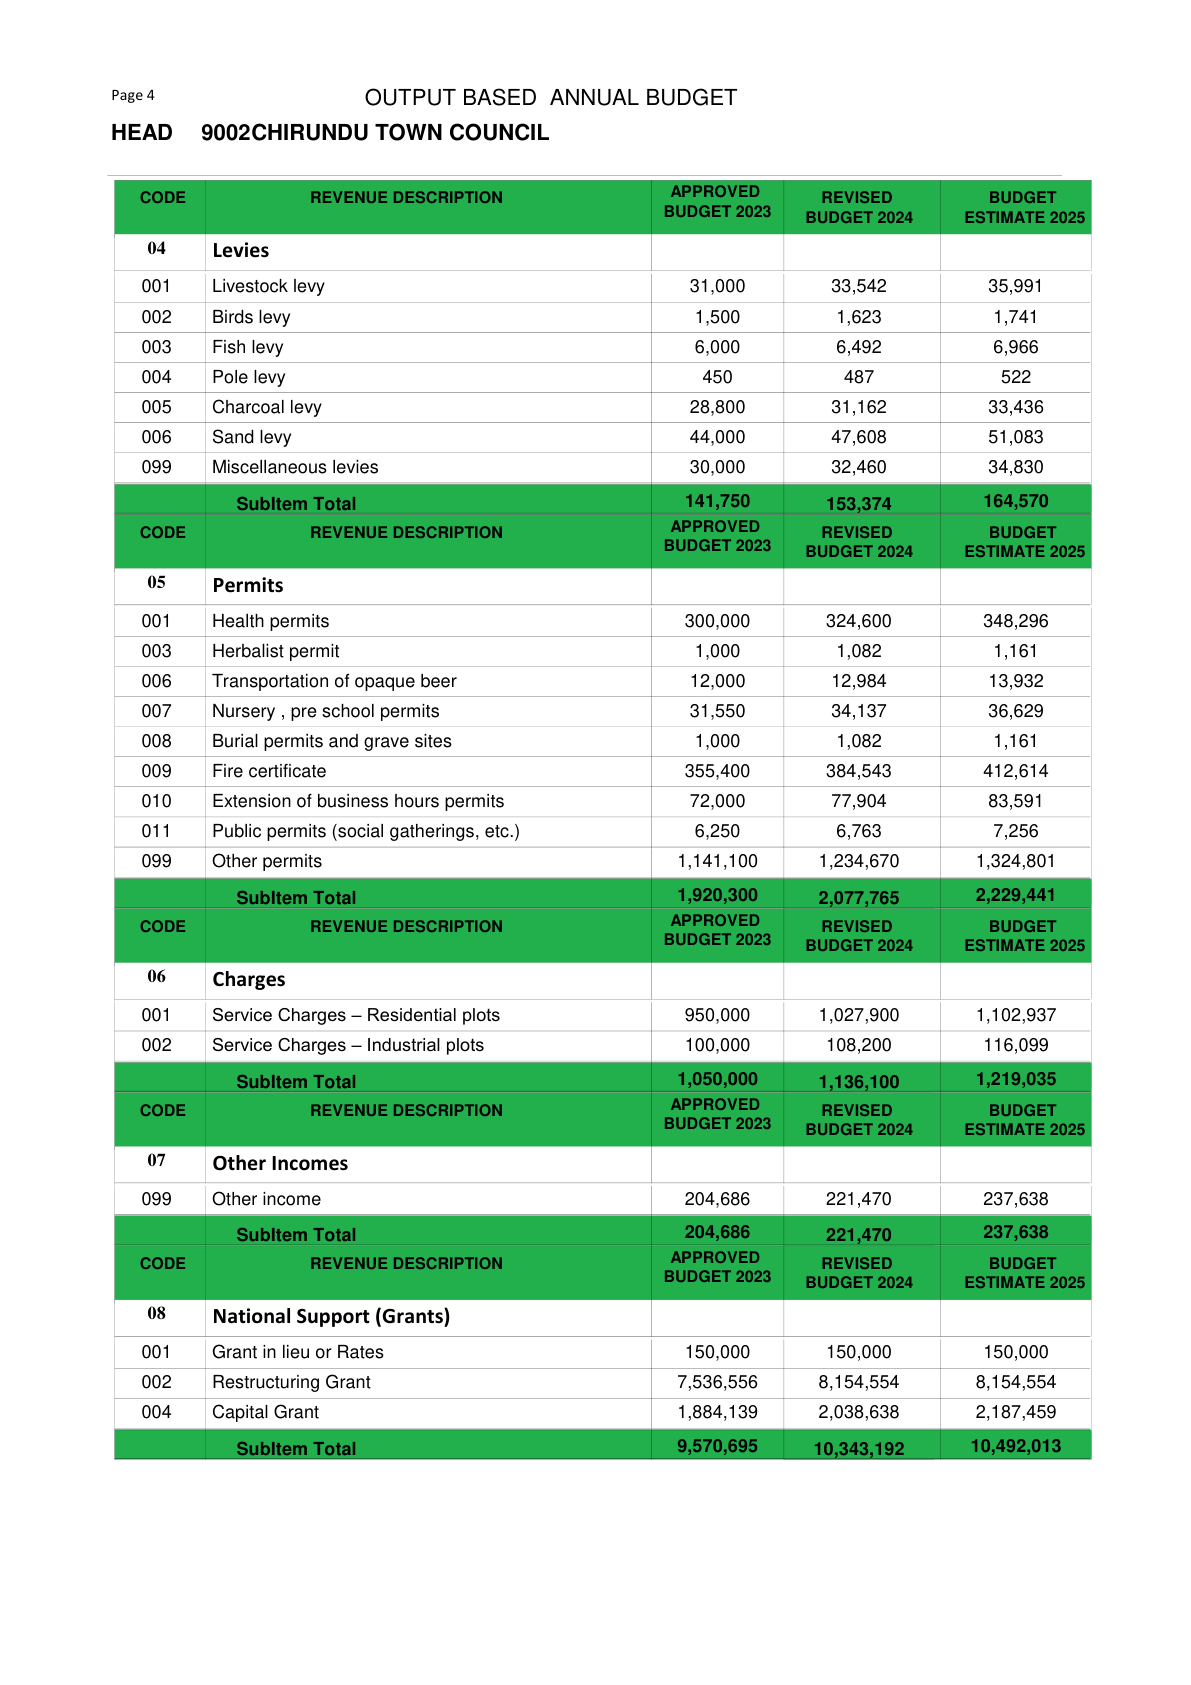

Page 4

OUTPUT BASED ANNUAL BUDGET

HEAD 9002CHIRUNDU TOWN COUNCIL

04 Levies

001 Livestock levy 31,000 33,542 35,991
002 Birds levy 1,500 1,623 1,741
003 Fish levy 6,000 6,492 6,966
004 Pole levy 450 487 522
005 Charcoal levy 28,800 31,162 33,436
006 Sand levy 44,000 47,608 51,083
099 Miscellaneous levies 30,000 32,460 34,830

05 Permits
001 Health permits 300,000 324,600 348,296
003 Herbalist permit 1,000 1,082 1,161
006 Transportation of opaque beer 12,000 12,984 13,932
007 Nursery , pre school permits 31,550 34,137 36,629
008 Burial permits and grave sites 1,000 1,082 1,161
009 Fire certificate 355,400 384,543 412,614
010 Extension of business hours permits 72,000 77,904 83,591
011 Public permits (social gatherings, etc.) 6,250 6,763 7,256
Other permits 1,141,100 1,234,670 1,324,801

001
002

Charges

Service Charges — Residential plots 950,000
Service Charges — Industrial plots 100,000

1,027,900
108,200

1,102,937
116,099

099

Other Incomes
Other income 204,686

221,470

237,63

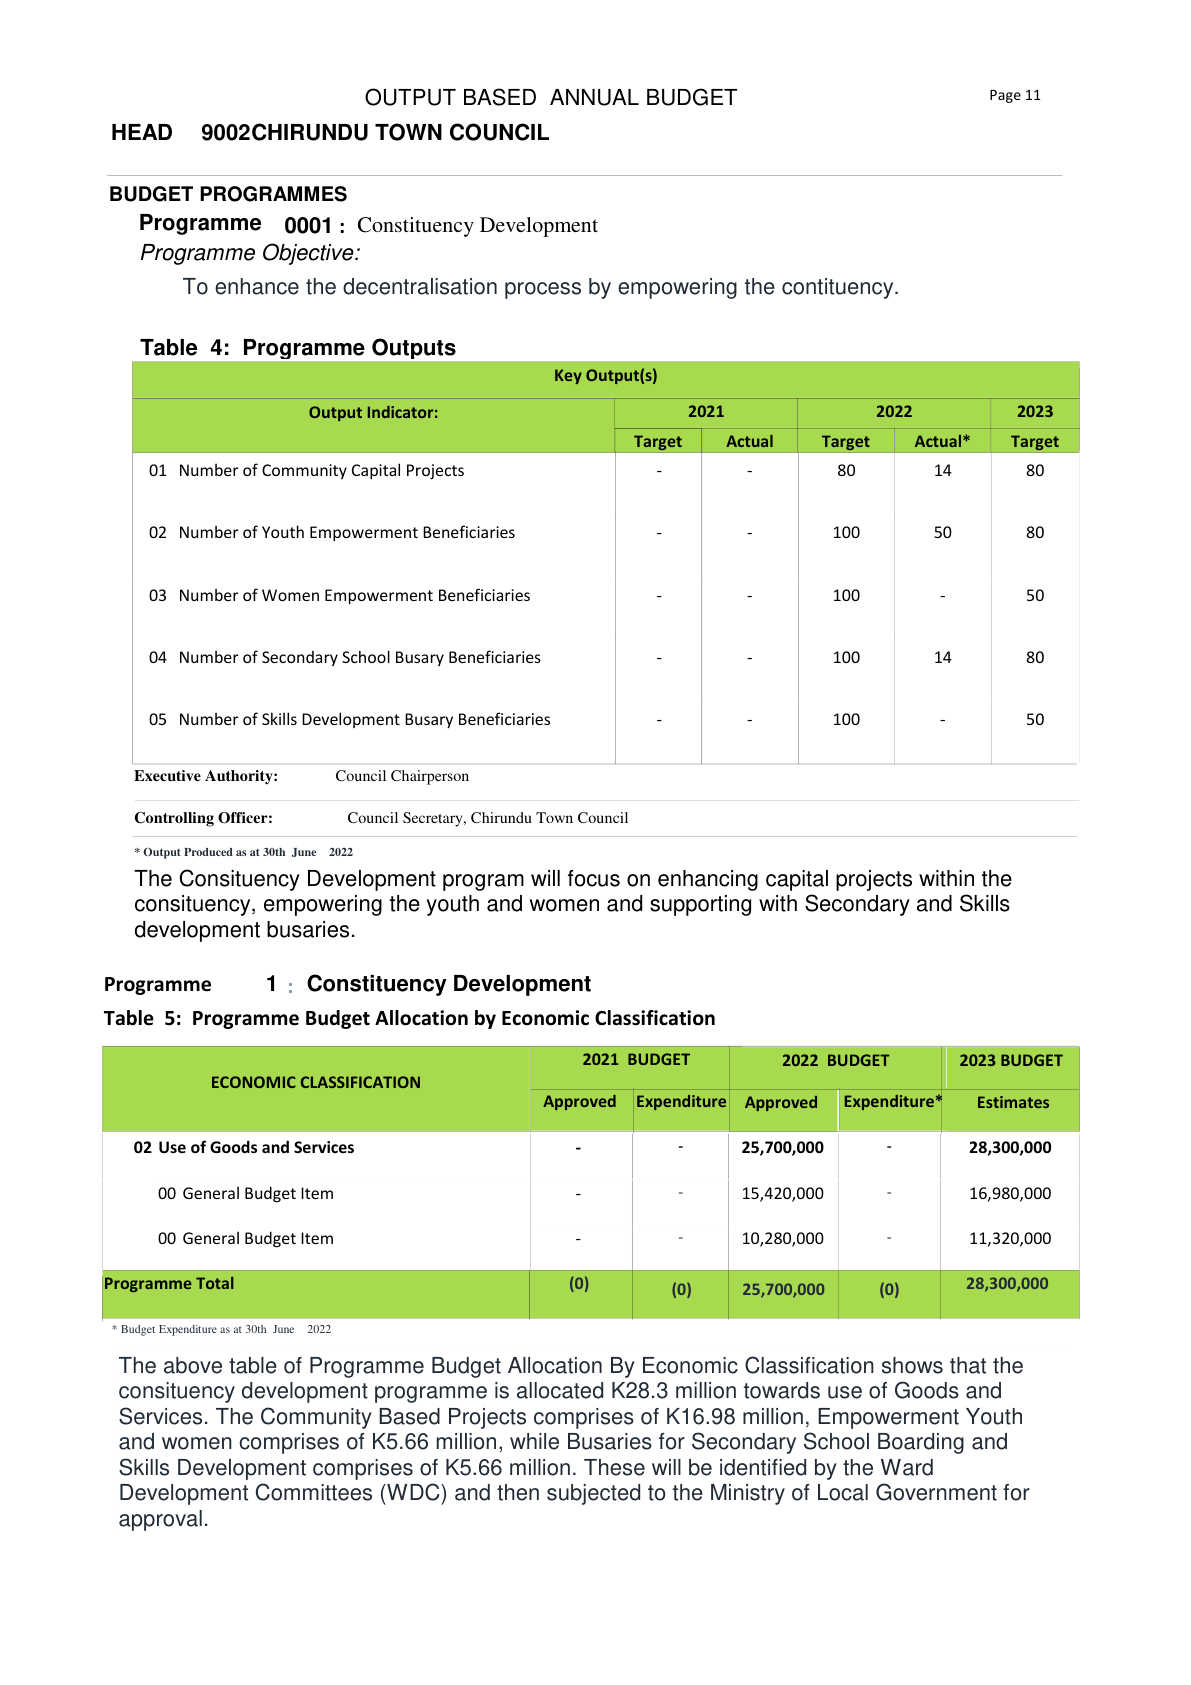

OUTPUT BASED ANNUAL BUDGET Page 11
HEAD 9002CHIRUNDU TOWN COUNCIL

BUDGET PROGRAMMES
Programme 0001 : Constituency Development
Programme Objective:

To enhance the decentralisation process by empowering the contituency.

Table 4: Programme Outputs

01 Number of Community Capital Projects - - 80 14 80
02. Number of Youth Empowerment Beneficiaries - - 100 50 80
03. Number of Women Empowerment Beneficiaries - - 100 - 50
04. Number of Secondary School Busary Beneficiaries - - 100 14 80
05 Number of Skills Development Busary Beneficiaries - - 100 - 50
Executive Authority: Council Chairperson
Controlling Officer: Council Secretary, Chirundu Town Council

* Output Produced as at 30th June 2022

The Consituency Development program will focus on enhancing capital projects within the
consituency, empowering the youth and women and supporting with Secondary and Skills
development busaries.

Programme 1: Constituency Development
Table 5: Programme Budget Allocation by Economic Classification

02 U

In [16]:
for page_number in [4, 11]:
    page = document.load_page(page_number - 1)
    pix = page.get_pixmap(matrix=pymupdf.Matrix(2, 2), alpha=False)
    image = Image.open(io.BytesIO(pix.tobytes("png")))

    print(f"\n{'=' * 70}")
    print(f"PAGE {page_number}")
    print(f"{'=' * 70}")

    display(image)
    print(raw_ocr.loc[raw_ocr["page"] == page_number, "ocr_text"].iloc[0])

In [17]:
cdf_budget_rows = [
    {
        "year": 2023,
        "category": "CDF",
        "programme_or_output": "Constituency Development Programme",
        "page": 11,
        "budget_amount": 28300000,
        "currency": "ZMW",
        "notes": "Total allocation towards use of goods and services: K28.3 million.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "CDF",
        "programme_or_output": "Community-Based Projects",
        "page": 11,
        "budget_amount": 16980000,
        "currency": "ZMW",
        "notes": "CDF allocation for community-based projects.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "CDF",
        "programme_or_output": "Youth and Women Empowerment",
        "page": 11,
        "budget_amount": 5660000,
        "currency": "ZMW",
        "notes": "CDF allocation for youth and women empowerment.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "CDF",
        "programme_or_output": "Secondary Boarding and Skills Development Bursaries",
        "page": 11,
        "budget_amount": 5660000,
        "currency": "ZMW",
        "notes": "CDF allocation for bursaries.",
        "source_file": pdf_path.name
    }
]

final_2023 = pd.concat(
    [final_2023, pd.DataFrame(cdf_budget_rows)],
    ignore_index=True
)

final_2023.to_csv(final_csv, index=False)

print("Rows in cleaned CSV:", len(final_2023))

Rows in cleaned CSV: 19


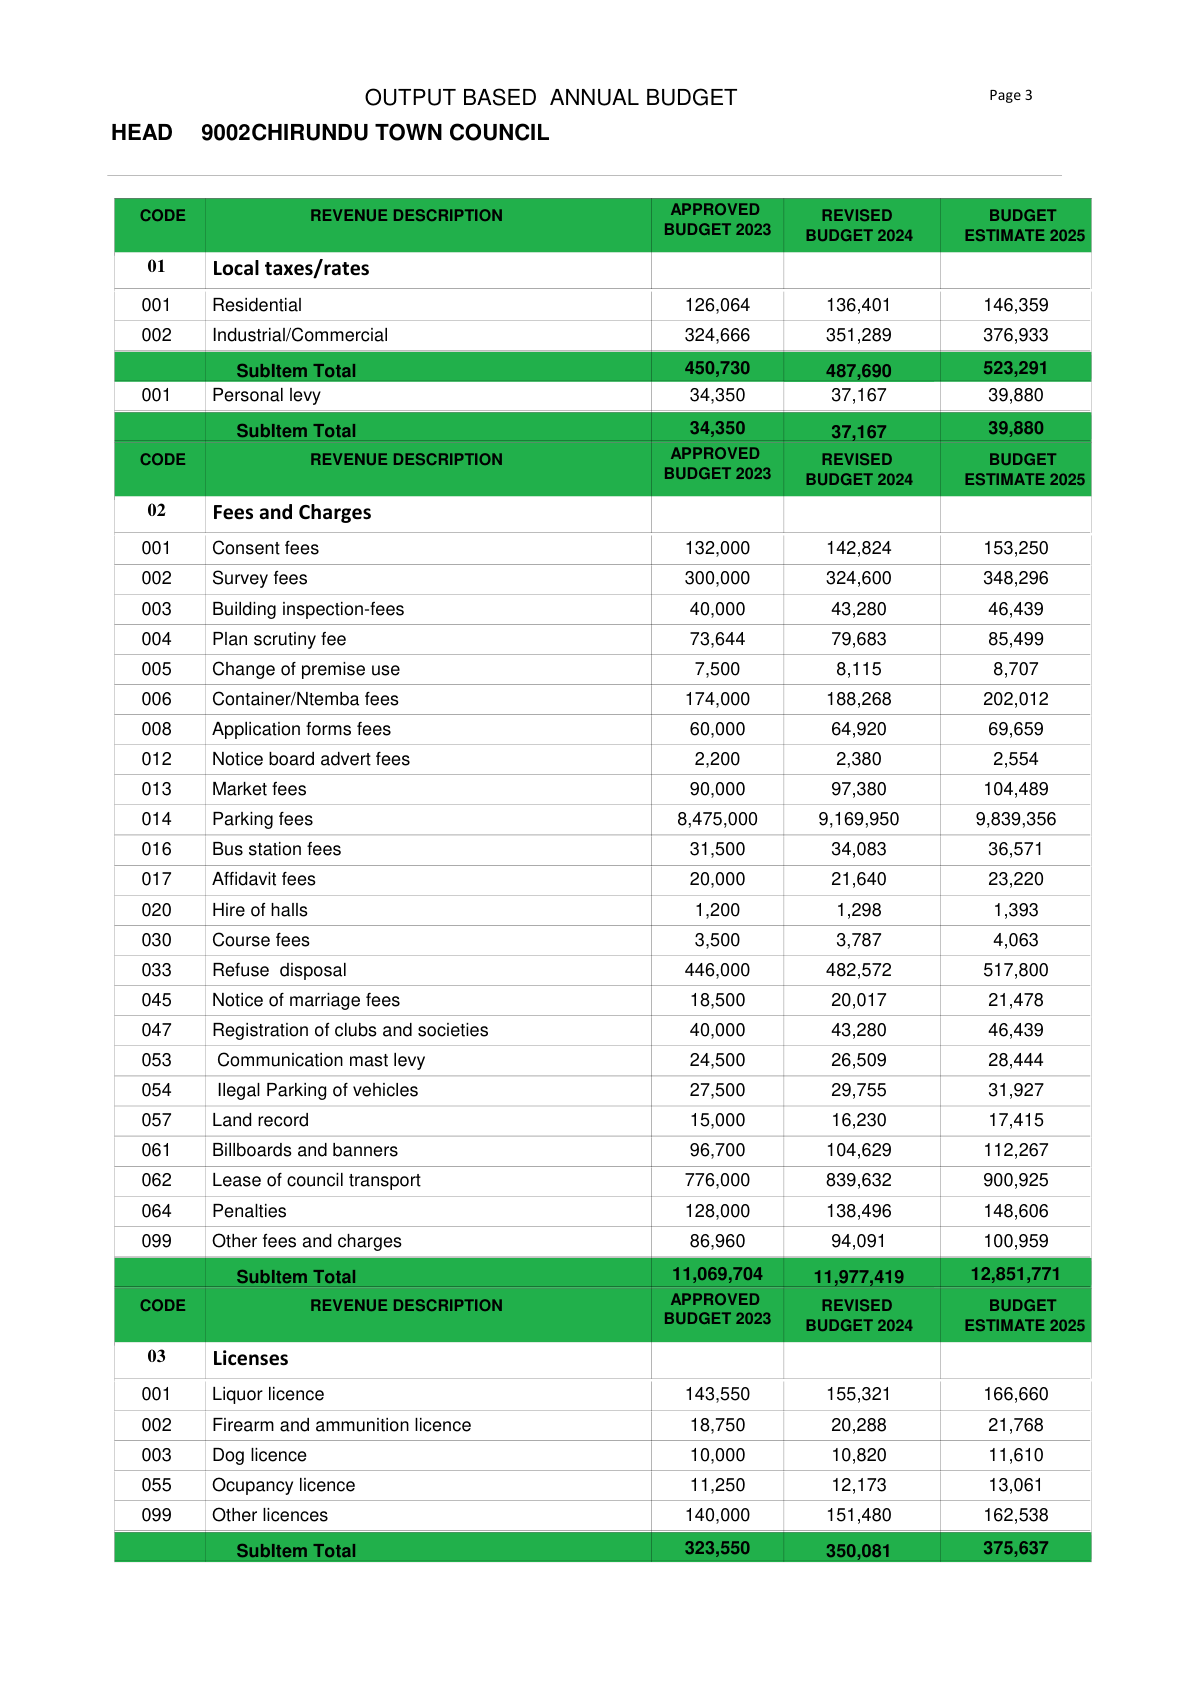

OUTPUT BASED ANNUAL BUDGET Page 3
HEAD 9002CHIRUNDU TOWN COUNCIL

o1 Local taxes/rates

001 Residential 126,064 136,401 146,359
002 Industrial/Commercial 324,666 351,289 376,933
001 Personal levy 34,350 37,167 39,880

02 Fees and Charges

001 Consent fees 132,000 142,824 153,250
002 Survey fees 300,000 324,600 348,296
003 Building inspection-fees 40,000 43,280 46,439
004 Plan scrutiny fee 73,644 79,683 85,499
005 Change of premise use 7,500 8,115 8,707
006 Container/Ntemba fees 174,000 188,268 202,012
008 Application forms fees 60,000 64,920 69,659
012 Notice board advert fees 2,200 2,380 2,554
013 Market fees 90,000 97,380 104,489
014 Parking fees 8,475,000 9,169,950 9,839,356
016 Bus station fees 31,500 34,083 36,571
017 Affidavit fees 20,000 21,640 23,220
020 Hire of halls 1,200 1,298 1,393
030 Course fees 3,500 3,787 4,063
033 Refuse disposal 446,000 482,572 517,800
045 Notice of marriage fees 18,500 20,017 21,478
047 Registration of clubs and societies 40,000 43,280 46,439
053 Com

In [18]:
page_number = 3

page = document.load_page(page_number - 1)
pix = page.get_pixmap(matrix=pymupdf.Matrix(2, 2), alpha=False)
image = Image.open(io.BytesIO(pix.tobytes("png")))

display(image)
print(raw_ocr.loc[raw_ocr["page"] == page_number, "ocr_text"].iloc[0])

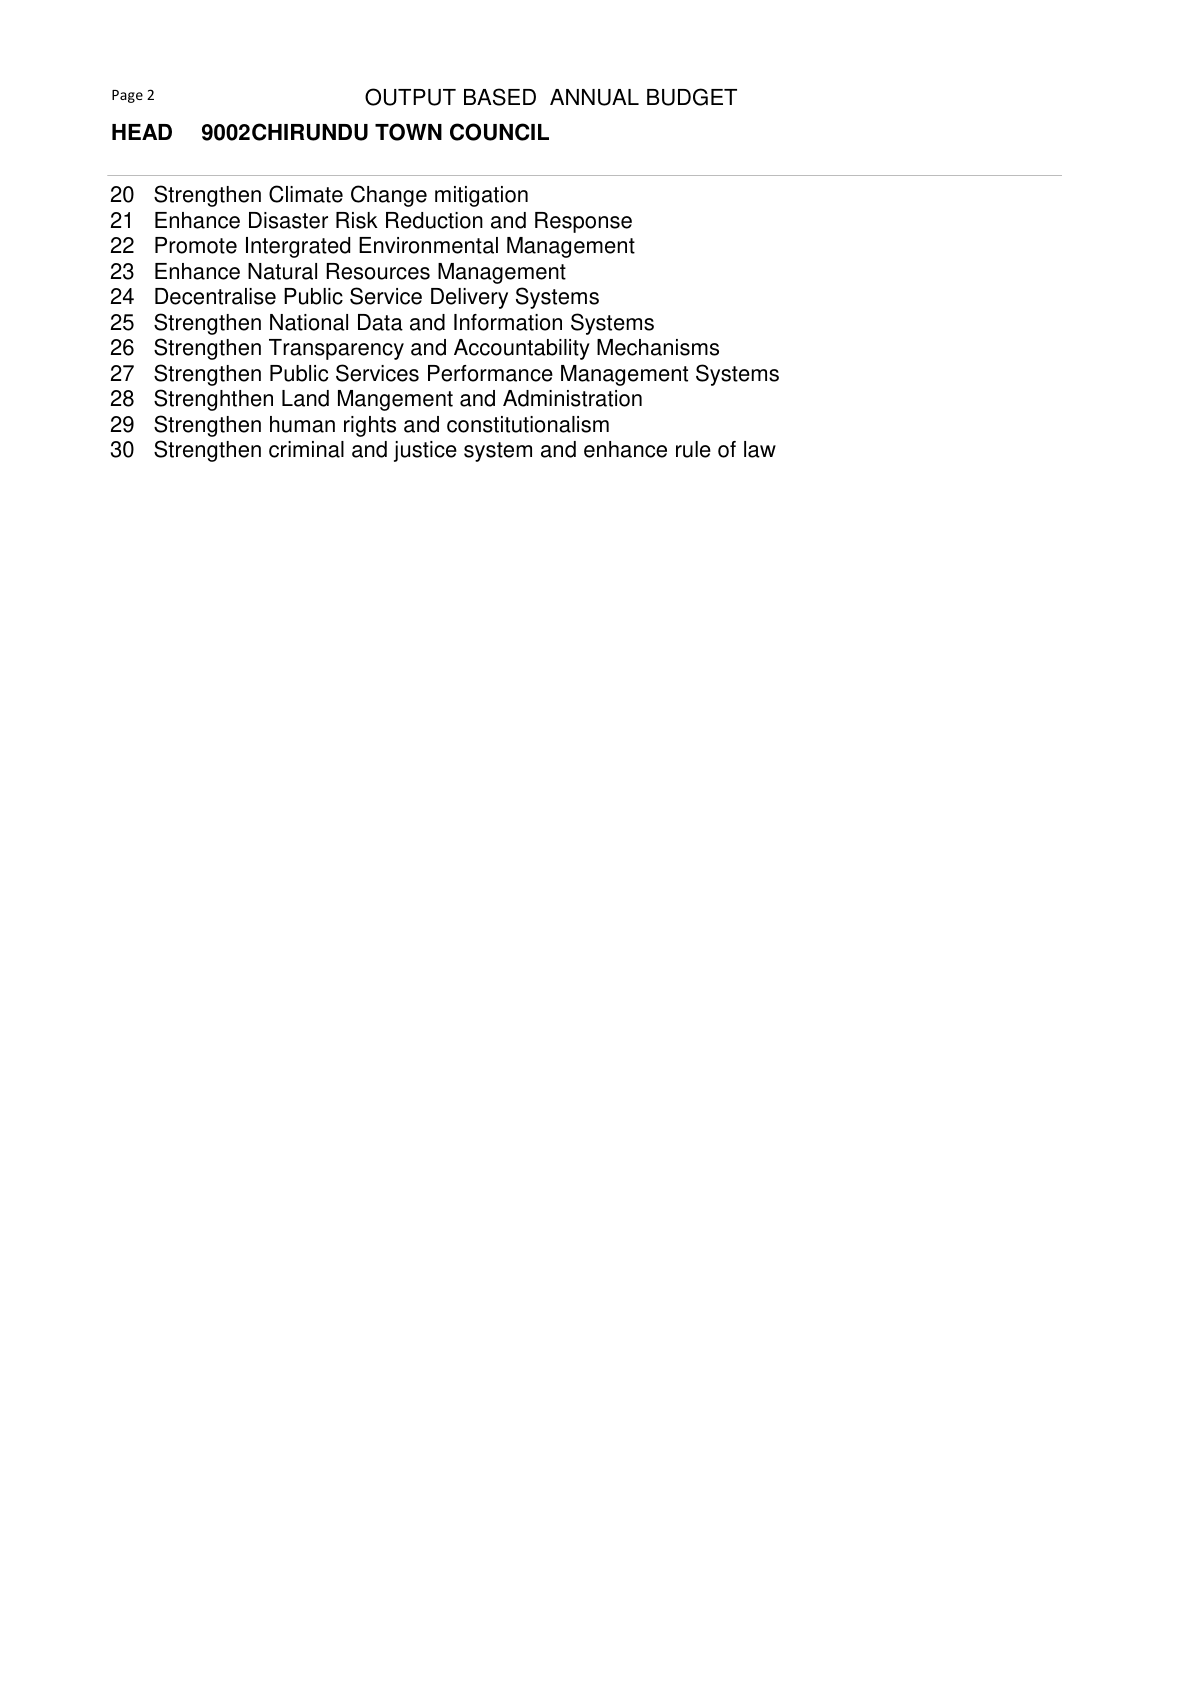

Page 2

OUTPUT BASED ANNUAL BUDGET

HEAD 9002CHIRUNDU TOWN COUNCIL

20
21
22
23
24
25
26
27
28
29
30

Strengthen Climate Change mitigation

Enhance Disaster Risk Reduction and Response

Promote Intergrated Environmental Management

Enhance Natural Resources Management

Decentralise Public Service Delivery Systems

Strengthen National Data and Information Systems

Strengthen Transparency and Accountability Mechanisms
Strengthen Public Services Performance Management Systems
Strenghthen Land Mangement and Administration

Strengthen human rights and constitutionalism

Strengthen criminal and justice system and enhance rule of law



In [19]:
page_number = 2

page = document.load_page(page_number - 1)
pix = page.get_pixmap(matrix=pymupdf.Matrix(2, 2), alpha=False)
image = Image.open(io.BytesIO(pix.tobytes("png")))

display(image)
print(raw_ocr.loc[raw_ocr["page"] == page_number, "ocr_text"].iloc[0])

In [20]:
local_revenue_columns = [
    "year",
    "revenue_type",
    "revenue_item",
    "page",
    "amount_1",
    "amount_2",
    "amount_3",
    "currency",
    "source_file"
]

local_revenue_2023 = pd.DataFrame(columns=local_revenue_columns)

In [21]:
local_revenue_rows = [
    {
        "year": 2023,
        "revenue_type": "Local Taxes/Rates",
        "revenue_item": "Residential",
        "page": 3,
        "amount_1": 126064,
        "amount_2": 136401,
        "amount_3": 146359,
        "currency": "ZMW",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "revenue_type": "Local Taxes/Rates",
        "revenue_item": "Industrial/Commercial",
        "page": 3,
        "amount_1": 324666,
        "amount_2": 351289,
        "amount_3": 376933,
        "currency": "ZMW",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "revenue_type": "Local Taxes/Rates",
        "revenue_item": "Personal Levy",
        "page": 3,
        "amount_1": 34350,
        "amount_2": 37167,
        "amount_3": 39880,
        "currency": "ZMW",
        "source_file": pdf_path.name
    }
]

local_revenue_2023 = pd.DataFrame(local_revenue_rows)
local_revenue_2023

,year,revenue_type,revenue_item,page,amount_1,amount_2,amount_3,currency,source_file
0,2023,Local Taxes/Rates,Residential,3,126064,136401,146359,ZMW,chirundu_obb_2023.pdf.pdf
1,2023,Local Taxes/Rates,Industrial/Commercial,3,324666,351289,376933,ZMW,chirundu_obb_2023.pdf.pdf
2,2023,Local Taxes/Rates,Personal Levy,3,34350,37167,39880,ZMW,chirundu_obb_2023.pdf.pdf


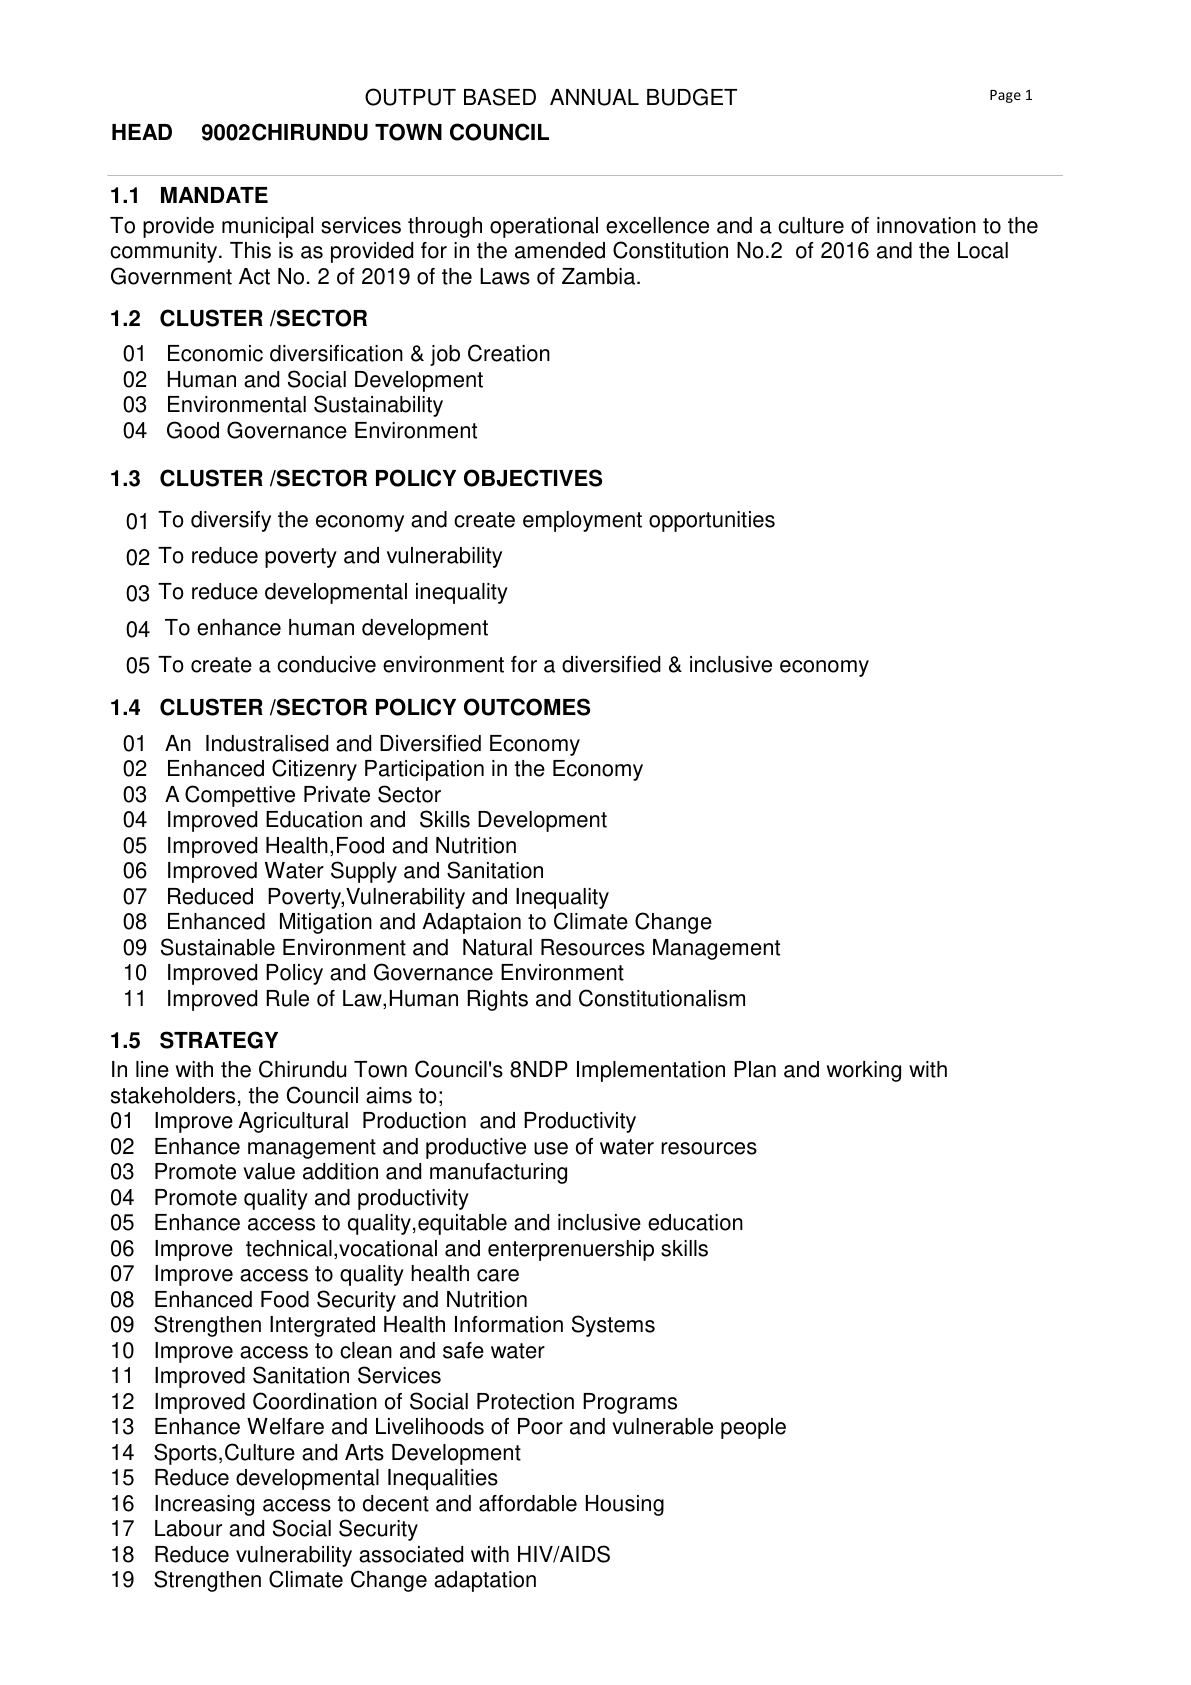

OUTPUT BASED ANNUAL BUDGET Page 1
HEAD 9002CHIRUNDU TOWN COUNCIL

1.1. MANDATE

To provide municipal services through operational excellence and a culture of innovation to the
community. This is as provided for in the amended Constitution No.2 of 2016 and the Local
Government Act No. 2 of 2019 of the Laws of Zambia.

1.2 CLUSTER /SECTOR

01 Economic diversification & job Creation
02 Human and Social Development

03 Environmental Sustainability

04 Good Governance Environment

1.3. CLUSTER /SECTOR POLICY OBJECTIVES
01 To diversify the economy and create employment opportunities
02 To reduce poverty and vulnerability
03 To reduce developmental inequality
04 To enhance human development
05 To create a conducive environment for a diversified & inclusive economy

1.4 CLUSTER /SECTOR POLICY OUTCOMES

01 An Industralised and Diversified Economy

02 Enhanced Citizenry Participation in the Economy

03 ACompettive Private Sector

04 Improved Education and Skills Development

05 Improved Health,F

In [22]:
page_number = 1

page = document.load_page(page_number - 1)
pix = page.get_pixmap(matrix=pymupdf.Matrix(2, 2), alpha=False)
image = Image.open(io.BytesIO(pix.tobytes("png")))

display(image)
print(raw_ocr.loc[raw_ocr["page"] == page_number, "ocr_text"].iloc[0])

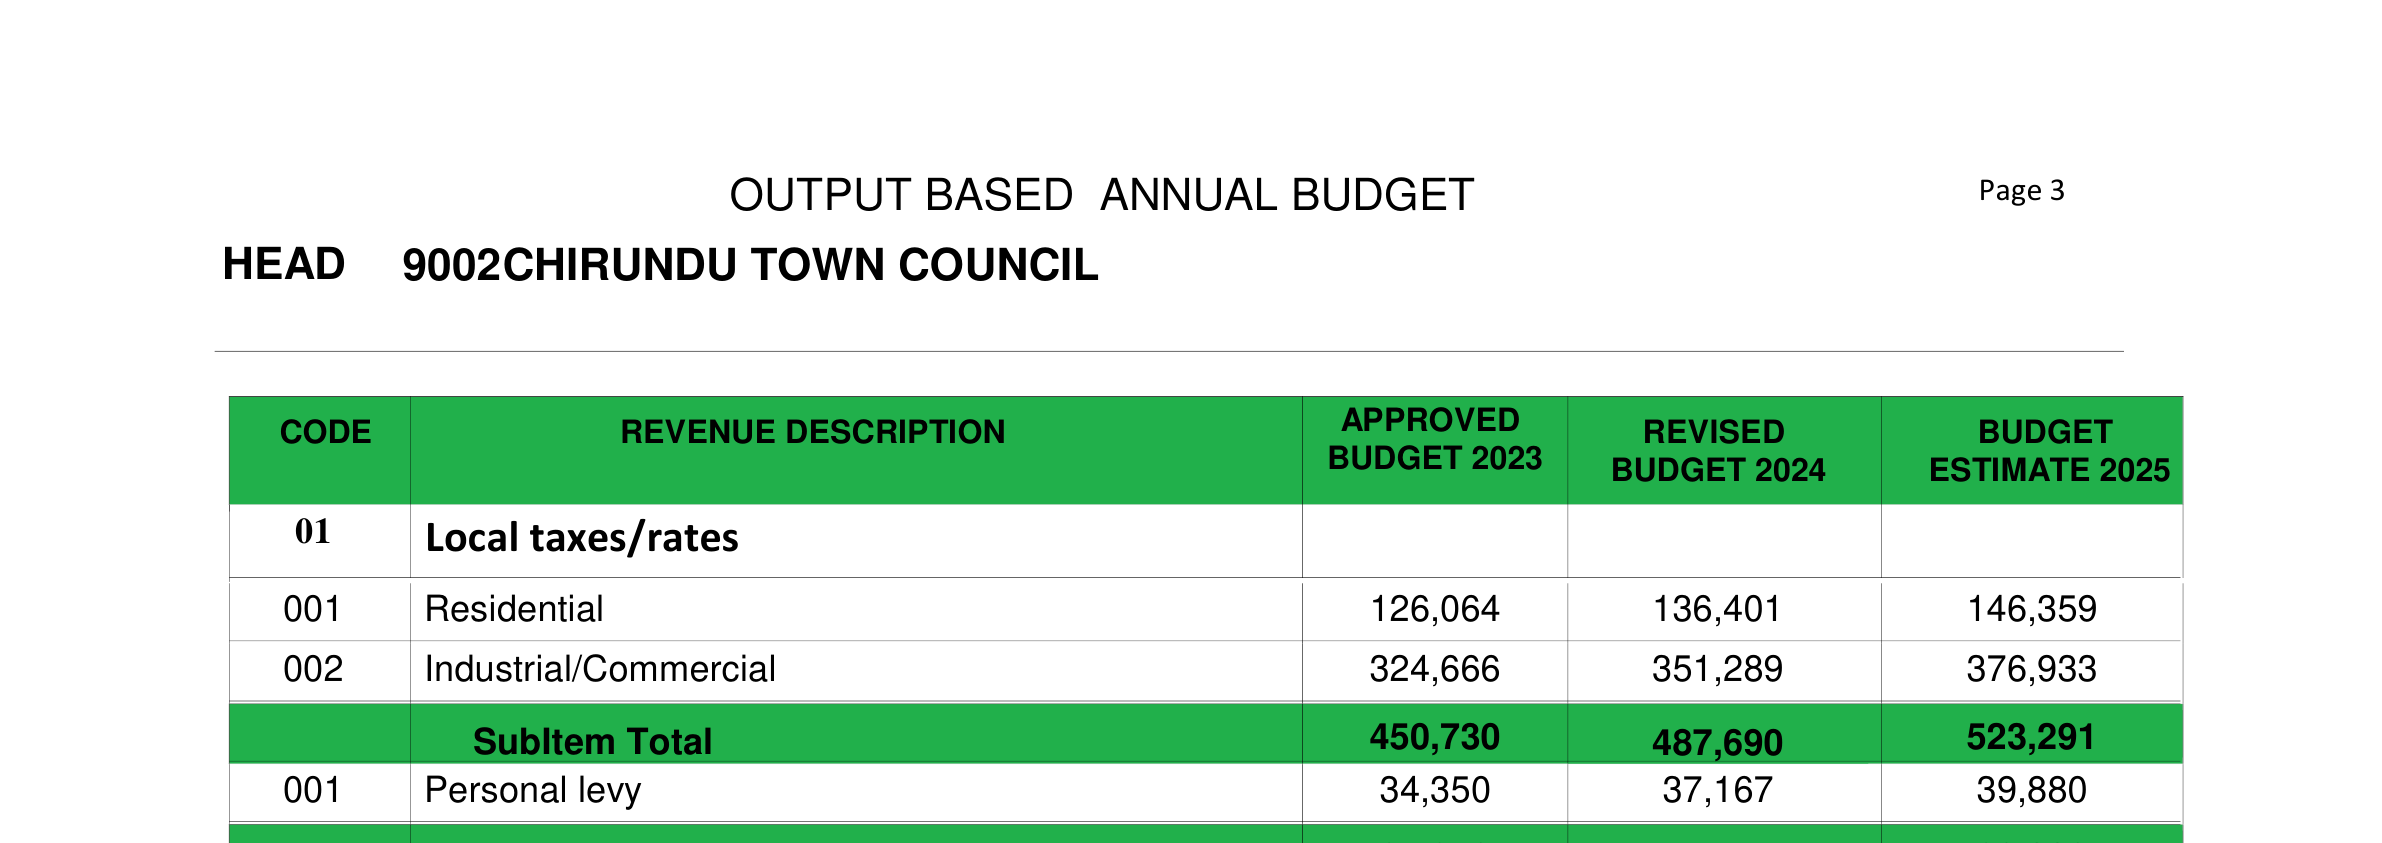

OUTPUT BASED ANNUAL BUDGET Page 3
HEAD 9002CHIRUNDU TOWN COUNCIL
EM eatin
001 Residential 126,064 136,401 146,359



In [23]:
page = document.load_page(2)  # page 3

top_section = pymupdf.Rect(
    0,
    0,
    page.rect.width,
    page.rect.height * 0.25
)

pix = page.get_pixmap(
    matrix=pymupdf.Matrix(4, 4),
    clip=top_section,
    alpha=False
)

header_image = Image.open(io.BytesIO(pix.tobytes("png")))
display(header_image)

header_text = pytesseract.image_to_string(
    header_image,
    lang="eng",
    config="--psm 6"
)

print(header_text)

In [24]:
import re
import pandas as pd

revenue_rows = []
current_type = ""

for page_number in [3, 4]:
    page_text = raw_ocr.loc[
        raw_ocr["page"] == page_number, "ocr_text"
    ].iloc[0]

    for raw_line in page_text.splitlines():
        line = raw_line.replace("|", " ").strip()

        # Detect revenue-section headings
        section = re.match(r"^0[1-5]\s+([A-Za-z][A-Za-z /&()-]+)$", line)
        if section:
            current_type = section.group(1)
            continue

        if line in ["Charges", "Other Incomes", "National Support (Grants)"]:
            current_type = line
            continue

        # Remove a three-digit item code, such as 001
        item_line = re.sub(r"^\d{3}\s+", "", line)

        # Extract an item followed by three monetary figures
        match = re.match(
            r"^(.+?)\s+([\d,]+)\s+([\d,]+)\s+([\d,]+)$",
            item_line
        )

        if match:
            revenue_rows.append({
                "year": 2023,
                "category": "Local Revenue",
                "revenue_type": current_type,
                "programme_or_output": match.group(1),
                "page": page_number,
                "amount_1": int(match.group(2).replace(",", "")),
                "amount_2": int(match.group(3).replace(",", "")),
                "amount_3": int(match.group(4).replace(",", "")),
                "currency": "ZMW",
                "notes": "Column headings were not OCR-readable; values retained in source order.",
                "source_file": pdf_path.name
            })

local_revenue_review = pd.DataFrame(revenue_rows)

display(local_revenue_review)
print("Revenue rows extracted:", len(local_revenue_review))

,year,category,revenue_type,programme_or_output,page,amount_1,amount_2,amount_3,currency,notes,source_file
0,2023,Local Revenue,,Residential,3,126064,136401,146359,ZMW,Column headings were not OCR-readable; values ...,chirundu_obb_2023.pdf.pdf
1,2023,Local Revenue,,Industrial/Commercial,3,324666,351289,376933,ZMW,Column headings were not OCR-readable; values ...,chirundu_obb_2023.pdf.pdf
2,2023,Local Revenue,,Personal levy,3,34350,37167,39880,ZMW,Column headings were not OCR-readable; values ...,chirundu_obb_2023.pdf.pdf
3,2023,Local Revenue,Fees and Charges,Consent fees,3,132000,142824,153250,ZMW,Column headings were not OCR-readable; values ...,chirundu_obb_2023.pdf.pdf
4,2023,Local Revenue,Fees and Charges,Survey fees,3,300000,324600,348296,ZMW,Column headings were not OCR-readable; values ...,chirundu_obb_2023.pdf.pdf
5,2023,Local Revenue,Fees and Charges,Building inspection-fees,3,40000,43280,46439,ZMW,Column headings were not OCR-readable; values ...,chirundu_obb_2023.pdf.pdf
6,2023,Local Revenue,Fees and Charges,Plan scrutiny fee,3,73644,79683,85499,ZMW,Column headings were not OCR-readable; values ...,chirundu_obb_2023.pdf.pdf
7,2023,Local Revenue,Fees and Charges,Change of premise use,3,7500,8115,8707,ZMW,Column headings were not OCR-readable; values ...,chirundu_obb_2023.pdf.pdf
8,2023,Local Revenue,Fees and Charges,Container/Ntemba fees,3,174000,188268,202012,ZMW,Column headings were not OCR-readable; values ...,chirundu_obb_2023.pdf.pdf
9,2023,Local Revenue,Fees and Charges,Application forms fees,3,60000,64920,69659,ZMW,Column headings were not OCR-readable; values ...,chirundu_obb_2023.pdf.pdf


Revenue rows extracted: 51


In [25]:
# Fix the missing revenue type for the first three rows
local_revenue_review.loc[
    local_revenue_review.index.isin([0, 1, 2]),
    "revenue_type"
] = "Local Taxes/Rates"

# Add rows that OCR split across separate lines
missing_revenue_rows = [
    {
        "year": 2023,
        "category": "Local Revenue",
        "revenue_type": "Charges",
        "programme_or_output": "Service Charges — Residential Plots",
        "page": 4,
        "amount_1": 950000,
        "amount_2": 1027900,
        "amount_3": 1102937,
        "currency": "ZMW",
        "notes": "Column headings were not OCR-readable; values retained in source order.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Local Revenue",
        "revenue_type": "Charges",
        "programme_or_output": "Service Charges — Industrial Plots",
        "page": 4,
        "amount_1": 100000,
        "amount_2": 108200,
        "amount_3": 116099,
        "currency": "ZMW",
        "notes": "Column headings were not OCR-readable; values retained in source order.",
        "source_file": pdf_path.name
    },
    {
        "year": 2023,
        "category": "Local Revenue",
        "revenue_type": "Other Incomes",
        "programme_or_output": "Other Income",
        "page": 4,
        "amount_1": 204686,
        "amount_2": 221470,
        "amount_3": 237638,
        "currency": "ZMW",
        "notes": "Column headings were not OCR-readable; values retained in source order.",
        "source_file": pdf_path.name
    }
]

local_revenue_review = pd.concat(
    [local_revenue_review, pd.DataFrame(missing_revenue_rows)],
    ignore_index=True
)

# Add Local Revenue data to the one final CSV
final_2023 = pd.concat(
    [final_2023, local_revenue_review],
    ignore_index=True,
    sort=False
)

final_2023.to_csv(final_csv, index=False)

print("Final CSV rows:", len(final_2023))

Final CSV rows: 73


In [26]:
lgef_note = pd.DataFrame([{
    "year": 2023,
    "category": "LGEF",
    "programme_or_output": "Local Government Equalisation Fund",
    "page": "",
    "budget_amount": "",
    "currency": "ZMW",
    "notes": "Not separately identified in the OCR text or the reviewed grant pages.",
    "source_file": pdf_path.name
}])

final_2023 = pd.concat([final_2023, lgef_note], ignore_index=True, sort=False)
final_2023.to_csv(final_csv, index=False)

print("Final CSV rows:", len(final_2023))

Final CSV rows: 74


In [27]:
import re

programme_rows = []

for _, row in raw_ocr.iterrows():
    matches = re.findall(
        r"Programme\s+0*(\d+)\s*:\s*([^\n]+)",
        row["ocr_text"],
        flags=re.IGNORECASE
    )

    for number, name in matches:
        programme_rows.append({
            "programme_number": number,
            "programme_name": name.strip(),
            "page": row["page"]
        })

programme_index = (
    pd.DataFrame(programme_rows)
    .drop_duplicates()
    .sort_values(["programme_number", "page"])
)

display(programme_index)

,programme_number,programme_name,page
0,1,Constituency Development,11
17,10,Public Order and Safety,26
18,10,Public Order and Safety,27
19,11,Management and Support Services,28
20,11,Management and Support Services,29
21,12,Resource Mobilisation and Management,30
22,12,Resource Mobilisation and Management,31
2,2,Local Governance,12
3,2,Local Governance,13
4,3,Integrated Development Planning,14


In [28]:
unique_programmes = (
    programme_index
    .groupby(["programme_number", "programme_name"], as_index=False)["page"]
    .min()
)

programme_records = []

for _, item in unique_programmes.iterrows():
    programme_records.append({
        "year": 2023,
        "category": "Programme",
        "programme_or_output": item["programme_name"],
        "page": item["page"],
        "budget_amount": "",
        "currency": "",
        "notes": f"Programme {item['programme_number']} identified in the 2023 OBB.",
        "source_file": pdf_path.name
    })

final_2023 = pd.concat(
    [final_2023, pd.DataFrame(programme_records)],
    ignore_index=True,
    sort=False
)

final_2023.to_csv(final_csv, index=False)

print("Final CSV rows:", len(final_2023))

Final CSV rows: 86


In [29]:
output_rows = []

for _, programme in unique_programmes.iterrows():
    page_number = programme["page"]

    page_text = raw_ocr.loc[
        raw_ocr["page"] == page_number, "ocr_text"
    ].iloc[0]

    match = re.search(
        r"Table 4:\s*Programme Outputs(.*?)(?:Executive Authority|Controlling Officer)",
        page_text,
        flags=re.IGNORECASE | re.DOTALL
    )

    if match:
        for line in match.group(1).splitlines():
            line = line.strip()

            item = re.match(r"^(\d{2})\.?\s+(.+)$", line)

            if item:
                output_name = item.group(2)

                # Remove trailing table numbers while retaining the output name
                output_name = re.sub(
                    r"\s+(?:-|\d[\d,]*)(?:\s+(?:-|\d[\d,]*))*\s*$",
                    "",
                    output_name
                ).strip()

                output_rows.append({
                    "year": 2023,
                    "programme_number": programme["programme_number"],
                    "programme_name": programme["programme_name"],
                    "page": page_number,
                    "output_number": item.group(1),
                    "output_name": output_name,
                    "source_file": pdf_path.name
                })

outputs_review = pd.DataFrame(output_rows)

display(outputs_review)
print("Output rows found:", len(outputs_review))

,year,programme_number,programme_name,page,output_number,output_name,source_file
0,2023,1,Constituency Development,11,01,Number of Community Capital Projects,chirundu_obb_2023.pdf.pdf
1,2023,1,Constituency Development,11,02,Number of Youth Empowerment Beneficiaries,chirundu_obb_2023.pdf.pdf
2,2023,1,Constituency Development,11,03,Number of Women Empowerment Beneficiaries,chirundu_obb_2023.pdf.pdf
3,2023,1,Constituency Development,11,04,Number of Secondary School Busary Beneficiaries,chirundu_obb_2023.pdf.pdf
4,2023,1,Constituency Development,11,05,Number of Skills Development Busary Beneficiaries,chirundu_obb_2023.pdf.pdf
...,...,...,...,...,...,...,...
65,2023,9,Social Protection,25,01,Number Adolescence & Young People Reached,chirundu_obb_2023.pdf.pdf
66,2023,9,Social Protection,25,02,Number of CATFs Trained,chirundu_obb_2023.pdf.pdf
67,2023,9,Social Protection,25,03,Number of Commemorations Held,chirundu_obb_2023.pdf.pdf
68,2023,9,Social Protection,25,04,Number of Communities Reached,chirundu_obb_2023.pdf.pdf


Output rows found: 70


In [30]:
output_records = []

for _, item in outputs_review.iterrows():
    output_records.append({
        "year": item["year"],
        "category": "Programme Output",
        "programme_or_output": item["output_name"],
        "page": item["page"],
        "budget_amount": "",
        "currency": "",
        "notes": (
            f"Programme {item['programme_number']}: "
            f"{item['programme_name']}; Output {item['output_number']}."
        ),
        "source_file": item["source_file"]
    })

final_2023 = pd.concat(
    [final_2023, pd.DataFrame(output_records)],
    ignore_index=True,
    sort=False
)

final_2023.to_csv(final_csv, index=False)

print("Final CSV rows:", len(final_2023))

Final CSV rows: 156


In [31]:
print(final_2023["category"].value_counts())

category
Programme Output        74
Local Revenue           58
Programme               12
CDF                      6
Local Revenue Output     5
LGEF                     1
Name: count, dtype: int64


In [32]:
from pathlib import Path
import pandas as pd

downloads = Path(r"C:\Users\USER\Downloads")

for year in [2023, 2024]:
    old_file = downloads / (
        f"db-unza26-csc4792-chirundu_town_council_{year}_extracted.xls"
    )

    new_file = downloads / (
        f"db-unza26-csc4792-chirundu_town_council_{year}_extracted.csv"
    )

    df = pd.read_csv(old_file, sep=",")

    df.to_csv(
        new_file,
        sep="|",
        index=False,
        encoding="utf-8-sig"
    )

    print(f"Created: {new_file.name} - {len(df)} rows")

Created: db-unza26-csc4792-chirundu_town_council_2023_extracted.csv - 156 rows
Created: db-unza26-csc4792-chirundu_town_council_2024_extracted.csv - 78 rows
